In [1]:
# --- CELL 1: SETUP & IMPORTS ---
!pip install segmentation-models-pytorch -q

import os
import glob
import random
import rasterio
import numpy as np
import pandas as pd
import shapely.wkt
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import mean_absolute_error, mean_squared_error

# PyTorch Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

# Ensure reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.0 MB/s eta 0:00:0000:01
Executing on: cuda


In [2]:
# --- CELL 2: FULL-TILE DATASET GENERATOR ---
BASE_DIR = '/kaggle/input/datasets/sandhiwangiyana/spacenet-6-multisensor-allweather-mapping' 
RGB_DIR = os.path.join(BASE_DIR, 'AOI_11_Rotterdam/PS-RGB')
SAR_DIR = os.path.join(BASE_DIR, 'AOI_11_Rotterdam/SAR-Intensity')
CSV_PATH = os.path.join(BASE_DIR, 'AOI_11_Rotterdam/SummaryData/SN6_Train_AOI_11_Rotterdam_Buildings.csv')

def load_optical(filepath):
    with rasterio.open(filepath) as src:
        img = src.read([1, 2, 3]) 
        img = np.moveaxis(img, 0, -1)
        img = np.nan_to_num(img, nan=0.0) # <--- NEW FIX: Cleans corrupted pixels
        max_val = np.max(img)
        if max_val > 0: img = img / max_val
    return img

def load_sar(filepath):
    with rasterio.open(filepath) as src:
        sar_img = src.read([1, 2, 3, 4]) 
        sar_img = np.moveaxis(sar_img, 0, -1) 
        sar_img = np.nan_to_num(sar_img, nan=0.0) # <--- NEW FIX: Cleans corrupted pixels
        p99 = np.percentile(sar_img, 99)
        sar_img = np.clip(sar_img, 0, p99)
        if p99 > 0: sar_img = sar_img / p99 
    return sar_img

class SpaceNetTileDataset(Dataset):
    def __init__(self, rgb_dir, sar_dir, csv_path, num_images=100, img_size=512):
        self.img_size = img_size
        self.rgb_dir = rgb_dir
        self.sar_dir = sar_dir
        
        # Load the CSV and pick the images
        self.full_df = pd.read_csv(csv_path)
        all_rgb_files = sorted(glob.glob(os.path.join(rgb_dir, '*.tif')))
        
        # Let's pick files that actually have buildings in them
        self.valid_files = []
        for f in all_rgb_files:
            tile_str = 'tile_' + os.path.basename(f).split('_tile_')[-1].replace('.tif', '')
            if len(self.full_df[self.full_df['ImageId'].str.contains(tile_str)]) > 5:
                self.valid_files.append((f, tile_str))
                if len(self.valid_files) >= num_images: break
                
        print(f"Loaded {len(self.valid_files)} valid image tiles for training/testing.")

    def __len__(self):
        return len(self.valid_files)

    def __getitem__(self, idx):
        rgb_path, tile_str = self.valid_files[idx]
        sar_path = os.path.join(self.sar_dir, os.path.basename(rgb_path).replace('PS-RGB', 'SAR-Intensity'))
        
        # 1. Load Images (7 channels total)
        opt_img = load_optical(rgb_path)
        sar_img = load_sar(sar_path)
        combined_img = np.dstack((opt_img, sar_img)) # Shape: (H, W, 7)
        orig_h, orig_w = combined_img.shape[0], combined_img.shape[1]
        
        # 2. Create Blank Masks
        footprint_mask = np.zeros((orig_h, orig_w), dtype=np.float32)
        height_map = np.zeros((orig_h, orig_w), dtype=np.float32)
        
        # 3. Burn the polygons and heights into the masks
        tile_buildings = self.full_df[self.full_df['ImageId'].str.contains(tile_str)]
        for _, row in tile_buildings.iterrows():
            poly = shapely.wkt.loads(row['PolygonWKT_Pix'])
            if poly.is_empty: continue
            
            # Extract coordinates and draw
            coords = np.array(poly.exterior.coords, dtype=np.int32)
            cv2.fillPoly(footprint_mask, [coords], 1.0)
            
            # Use actual height column (adjust name if needed, usually 'height' or 'Mean_Building_Height')
            h = float(row.get('Mean_Building_Height', row.get('height', 10.0))) 
            cv2.fillPoly(height_map, [coords], h)
            
        # 4. Resize everything to 512x512 for U-Net
        combined_img = cv2.resize(combined_img, (self.img_size, self.img_size))
        footprint_mask = cv2.resize(footprint_mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
        height_map = cv2.resize(height_map, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
        
        # Convert to PyTorch Tensors: (C, H, W)
        tensor_img = torch.tensor(combined_img, dtype=torch.float32).permute(2, 0, 1)
        tensor_mask = torch.tensor(footprint_mask, dtype=torch.float32).unsqueeze(0)
        tensor_height = torch.tensor(height_map, dtype=torch.float32).unsqueeze(0)
        
        return tensor_img, tensor_mask, tensor_height, tile_str

In [5]:
# --- CELL 3: MULTI-TASK U-NET ARCHITECTURE ---
class WinningFusionUNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Pre-Trained Backbone (Takes 7 channels, outputs 64-channel features)
        self.base_model = smp.Unet(
            encoder_name="resnet34",        
            encoder_weights="imagenet",     
            in_channels=7,                  
            classes=64, 
        )
        
        # The Two Output Heads
        self.footprint_head = nn.Conv2d(64, 1, kernel_size=1)
        self.height_head = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        features = self.base_model(x)
        
        # Head 1: Probability of being a building (0.0 to 1.0)
        footprint_prob = torch.sigmoid(self.footprint_head(features))
        
        # Head 2: Raw height prediction in meters
        raw_height = torch.relu(self.height_head(features))
        
        # SEMANTIC REFINEMENT: Multiply height by footprint probability
        refined_height = raw_height * footprint_prob
        
        return footprint_prob, refined_height

In [9]:
# --- CELL 4: DUAL-LOSS TRAINING PIPELINE (FOCUSED & NORMALIZED) ---
BATCH_SIZE = 4
EPOCHS = 10
LEARNING_RATE = 1e-4
BEST_MODEL_PATH = "best_fusion_model.pth"
MAX_HEIGHT = 50.0 # <--- NEW: We normalize heights to a 0-50m scale

# 1. Initialize Dataset
print("Initializing Tile Dataset...")
full_dataset = SpaceNetTileDataset(RGB_DIR, SAR_DIR, CSV_PATH, num_images=120)

# Split into Train/Test
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 2. Initialize Model & Optimizers
model = WinningFusionUNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

criterion_footprint = nn.BCELoss() 
criterion_height = nn.MSELoss()    

# 3. Training Loop
print(f"Starting {EPOCHS}-epoch training loop...")
best_loss = float('inf')

for epoch in range(EPOCHS):
    model.train() 
    running_loss = 0.0
    
    for batch_imgs, batch_masks, batch_heights, _ in train_loader:
        batch_imgs = batch_imgs.to(device)
        batch_masks = batch_masks.to(device)
        batch_heights = batch_heights.to(device)
        
        # Scrub NaNs
        batch_imgs = torch.nan_to_num(batch_imgs, nan=0.0, posinf=1.0, neginf=0.0)
        batch_masks = torch.nan_to_num(batch_masks, nan=0.0).clamp(0.0, 1.0)
        
        # --- NEW: Normalize heights so the network learns faster ---
        batch_heights = torch.nan_to_num(batch_heights, nan=0.0)
        norm_batch_heights = batch_heights / MAX_HEIGHT 
        
        optimizer.zero_grad()
        
        # Predict both outputs
        pred_footprint, pred_height = model(batch_imgs)
        pred_footprint = torch.nan_to_num(pred_footprint, nan=0.0).clamp(1e-6, 1.0 - 1e-6)
        
        # 1. Footprint Loss (Normal)
        loss_fp = criterion_footprint(pred_footprint, batch_masks)
        
        # 2. MASKED Height Loss (The Magic Fix)
        # We ONLY care about the height error where the actual mask says a building exists.
        building_pixels = batch_masks > 0.5
        if building_pixels.sum() > 0:
            loss_h = criterion_height(pred_height[building_pixels], norm_batch_heights[building_pixels])
        else:
            loss_h = torch.tensor(0.0, requires_grad=True).to(device)
            
        # Give height loss a 5x multiplier so the network pays attention to it
        total_loss = loss_fp + (loss_h * 5.0) 
        
        total_loss.backward()
        optimizer.step()
        
        running_loss += total_loss.item()
        
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] - Total Loss: {avg_loss:.4f} (FP: {loss_fp.item():.4f}, Height: {loss_h.item():.4f})")
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save({'model_state_dict': model.state_dict()}, BEST_MODEL_PATH)
        print(" -> Checkpoint saved!")

Initializing Tile Dataset...
Loaded 120 valid image tiles for training/testing.
Starting 10-epoch training loop...
Epoch [01/10] - Total Loss: 0.8746 (FP: 0.6117, Height: 0.0455)
 -> Checkpoint saved!
Epoch [02/10] - Total Loss: 0.6865 (FP: 0.5933, Height: 0.0126)
 -> Checkpoint saved!
Epoch [03/10] - Total Loss: 0.5777 (FP: 0.4098, Height: 0.0141)
 -> Checkpoint saved!
Epoch [04/10] - Total Loss: 0.5190 (FP: 0.3741, Height: 0.0059)
 -> Checkpoint saved!
Epoch [05/10] - Total Loss: 0.4680 (FP: 0.3011, Height: 0.0055)
 -> Checkpoint saved!
Epoch [06/10] - Total Loss: 0.4345 (FP: 0.2572, Height: 0.0160)
 -> Checkpoint saved!
Epoch [07/10] - Total Loss: 0.4112 (FP: 0.3622, Height: 0.0102)
 -> Checkpoint saved!
Epoch [08/10] - Total Loss: 0.4073 (FP: 0.2412, Height: 0.0100)
 -> Checkpoint saved!
Epoch [09/10] - Total Loss: 0.3884 (FP: 0.2261, Height: 0.0315)
 -> Checkpoint saved!
Epoch [10/10] - Total Loss: 0.3849 (FP: 0.6539, Height: 0.0248)
 -> Checkpoint saved!


============== RESULTS FOR tile_6462 ==============
Model detected 33 distinct buildings in this scene.

Bldg Rank  | Predicted Height     | Actual Height (CSV) 
-------------------------------------------------------
#1         | 12.74 m               | 12.51 m
#2         | 12.11 m               | 10.74 m
#3         | 11.55 m               | 10.74 m
#4         | 11.09 m               | 10.46 m
#5         | 10.99 m               | 10.28 m
#6         | 10.80 m               | 7.21 m
#7         | 10.64 m               | 6.71 m

--- FINAL MVP SCORE ---
Mean Absolute Error (MAE): 1.61 meters
Root Mean Squared Error (RMSE): 2.13 meters


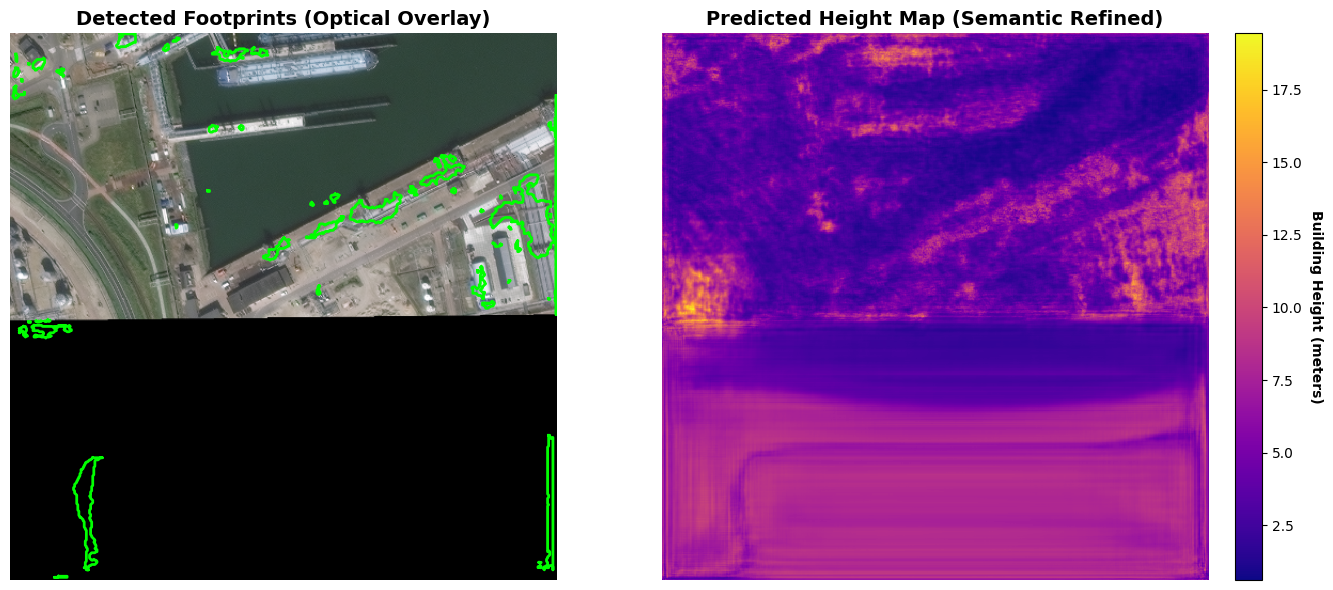

In [14]:
# --- CELL 5: ENHANCED INFERENCE & METRICS ---
import matplotlib.pyplot as plt
import cv2
import numpy as np

MAX_HEIGHT = 50.0 # Must match training cell

def extract_building_stats(footprint_prob, height_map, threshold=0.5, min_area=20):
    binary_mask = (footprint_prob > threshold).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)
    building_statistics = []
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            building_pixels = height_map[labels == i]
            building_statistics.append({
                'building_id': i,
                'avg_height': np.mean(building_pixels),
                'median_height': np.median(building_pixels),
                'std_height': np.std(building_pixels)
            })
    return building_statistics, binary_mask

# 1. Load the Best Model
model.load_state_dict(torch.load(BEST_MODEL_PATH)['model_state_dict'])
model.eval()

# 2. Test on a Validation Image
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)
sample_tensor, true_mask, true_height, tile_str = next(iter(test_loader))

with torch.no_grad():
    input_tensor = sample_tensor.to(device)
    pred_mask, pred_height = model(input_tensor)

# --- NEW: De-normalize the height back to real-world meters! ---
pred_height = pred_height * MAX_HEIGHT

# Convert to numpy for processing
pred_mask_np = pred_mask.squeeze().cpu().numpy()
pred_height_np = pred_height.squeeze().cpu().numpy()

# 3. Extract the stats and the final binary footprint mask
# predicted_buildings, final_binary_mask = extract_building_stats(pred_mask_np, pred_height_np)
predicted_buildings, final_binary_mask = extract_building_stats(pred_mask_np, pred_height_np, threshold=0.25, min_area=10)
# 4. Get Actual Heights from CSV
df = pd.read_csv(CSV_PATH)
gt_buildings = df[df['ImageId'].str.contains(tile_str[0])]
actual_heights = gt_buildings['Mean_Building_Height'].values

predicted_heights = [b['avg_height'] for b in predicted_buildings]
predicted_heights.sort(reverse=True)
actual_heights = sorted(actual_heights, reverse=True)
min_len = min(len(actual_heights), len(predicted_heights))

# TEXT OUTPUT
print(f"============== RESULTS FOR {tile_str[0]} ==============")
print(f"Model detected {len(predicted_buildings)} distinct buildings in this scene.\n")

if min_len > 0:
    print(f"{'Bldg Rank':<10} | {'Predicted Height':<20} | {'Actual Height (CSV)':<20}")
    print("-" * 55)
    for i in range(min(10, min_len)):
        print(f"#{i+1:<9} | {predicted_heights[i]:.2f} m{'':<14} | {actual_heights[i]:.2f} m")
    
    y_true = actual_heights[:min_len]
    y_pred = predicted_heights[:min_len]
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print("\n--- FINAL MVP SCORE ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f} meters")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f} meters")
else:
    print("Could not calculate MAE/RMSE.")

# VISUAL OUTPUT
opt_img = sample_tensor[0, :3, :, :].cpu().permute(1, 2, 0).numpy()
opt_img = np.clip(opt_img, 0, 1)

binary_mask_uint8 = (final_binary_mask * 255).astype(np.uint8)
contours, _ = cv2.findContours(binary_mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(opt_img)
axes[0].set_title("Detected Footprints (Optical Overlay)", fontsize=14, fontweight='bold')
axes[0].axis('off')

for c in contours:
    c = c.squeeze()
    if len(c.shape) == 2 and len(c) > 2:
        c = np.append(c, [c[0]], axis=0) 
        axes[0].plot(c[:, 0], c[:, 1], color='lime', linewidth=2)

masked_height = np.ma.masked_where(pred_height_np == 0, pred_height_np)
im = axes[1].imshow(masked_height, cmap='plasma', interpolation='nearest')
axes[1].set_title("Predicted Height Map (Semantic Refined)", fontsize=14, fontweight='bold')
axes[1].axis('off')

cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label('Building Height (meters)', rotation=270, labelpad=15, fontweight='bold')

plt.tight_layout()
plt.show()